## Customer Retention & Churn Analysis

### Future Interns – Data Science & Analytics Task 2

#### Business Problem

Customer churn is one of the most critical challenges for subscription-based businesses. Losing customers directly impacts revenue and growth.

This project analyzes customer behavior, identifies churn drivers, and provides recommendations to improve retention.

### Objectives

- Understand customer churn patterns
- Identify high-risk customer segments
- Analyze customer lifetime behavior
- Discover retention drivers
- Build a churn prediction model
- Provide business recommendations

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

sns.set_style("whitegrid")

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')

In [9]:
df['TotalCharges'].fillna(df['TotalCharges'].median(),inplace=True)

C:\Users\Munde Mahesh\AppData\Local\Temp\ipykernel_20204\3929950690.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['TotalCharges'].fillna(df['TotalCharges'].median(),inplace=True)


0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [10]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [11]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Customer Churn Analysis

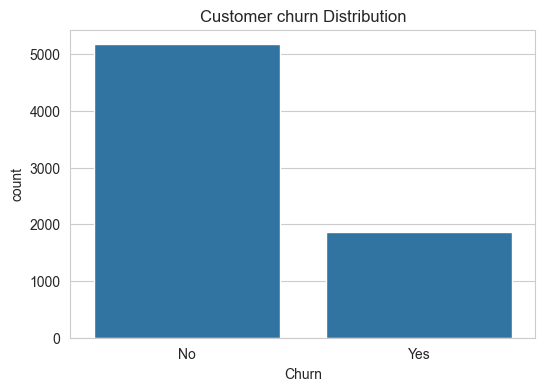

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(x='Churn',data=df)

plt.title("Customer churn Distribution")
plt.show()

In [13]:
churn_rate = (df['Churn'].value_counts(normalize=True)*100)
churn_rate

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

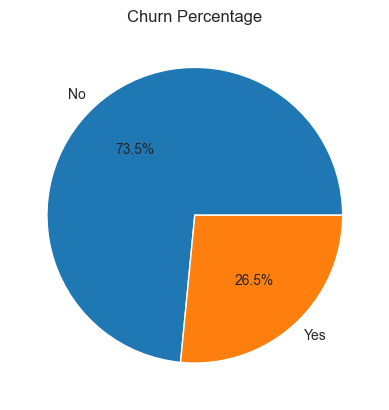

In [14]:
churn_rate.plot(kind='pie',autopct='%1.1f%%')

plt.ylabel("")
plt.title("Churn Percentage")
plt.show()

### Demographic Analysis

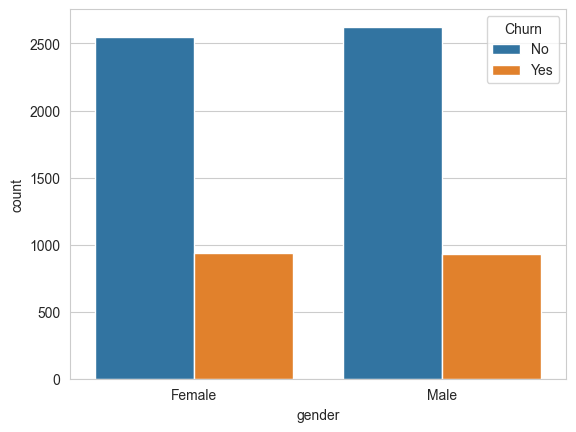

In [15]:
sns.countplot(x='gender',hue='Churn',data=df)

plt.show()

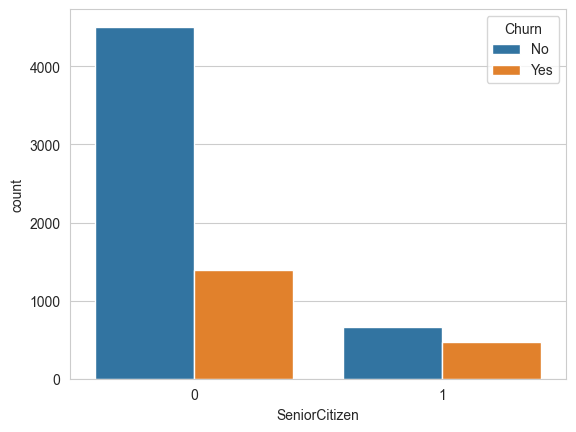

In [16]:
sns.countplot(x='SeniorCitizen', hue='Churn', data=df)

plt.show()

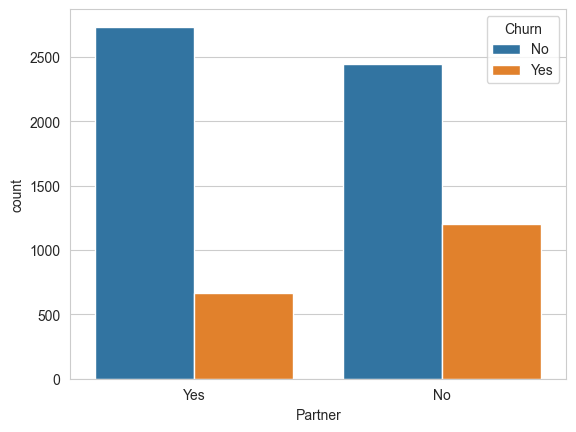

In [17]:
sns.countplot(x="Partner", hue="Churn", data=df)

plt.show()

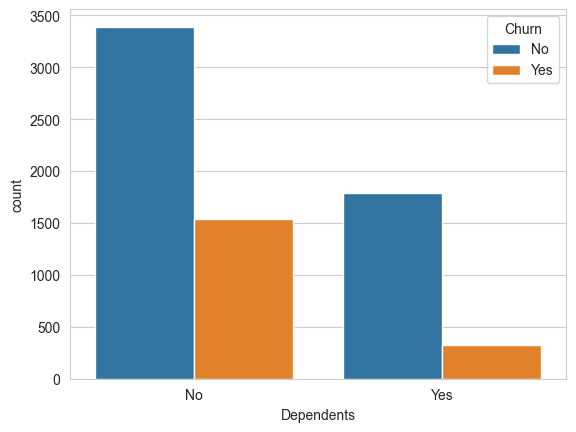

In [18]:
sns.countplot(x='Dependents', hue='Churn', data=df)
plt.show()

### Contract Analysis

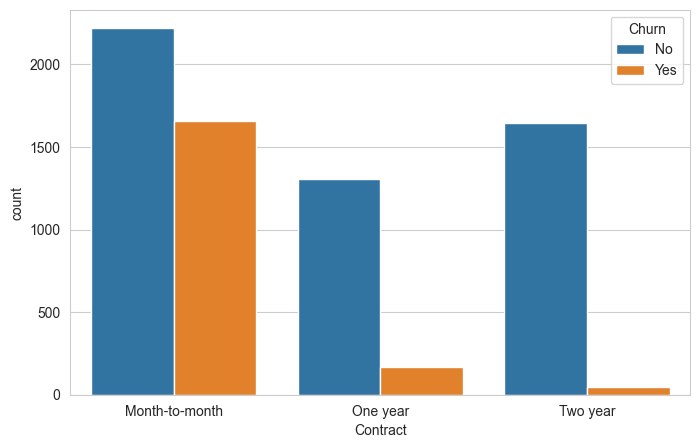

In [19]:
plt.figure(figsize=(8,5))

sns.countplot(x='Contract', hue='Churn', data=df)

plt.show()

In [20]:
pd.crosstab(df['Contract'], df['Churn'])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [21]:
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index')*100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


### Payment Method Analysis

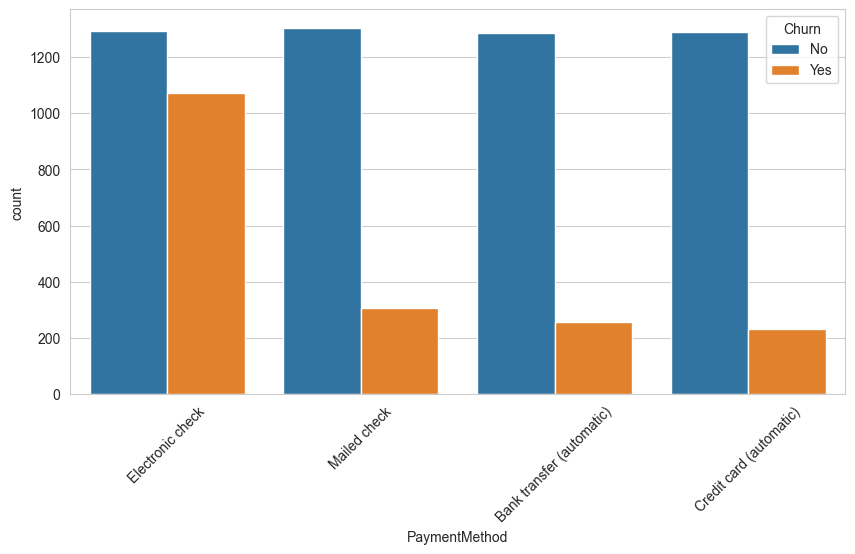

In [22]:
plt.figure(figsize=(10,5))

sns.countplot(x='PaymentMethod', hue='Churn', data=df)

plt.xticks(rotation=45)

plt.show()

In [23]:
pd.crosstab(df['PaymentMethod'], df['Churn'])

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


### Service Analysis

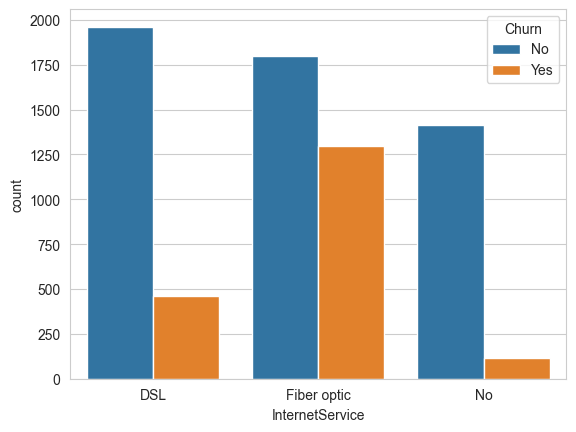

In [24]:
sns.countplot(x='InternetService', hue='Churn', data=df)

plt.show()

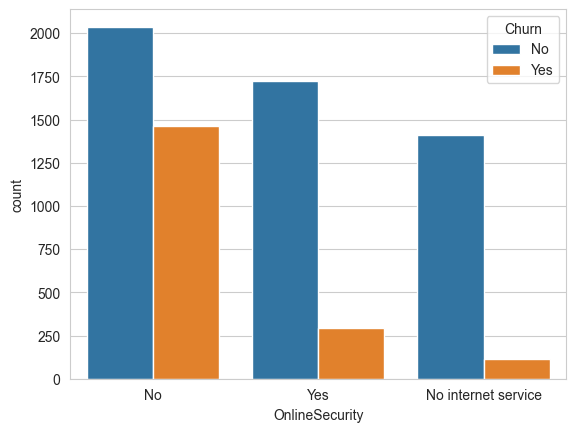

In [25]:
sns.countplot(x='OnlineSecurity', hue='Churn', data = df)

plt.show()

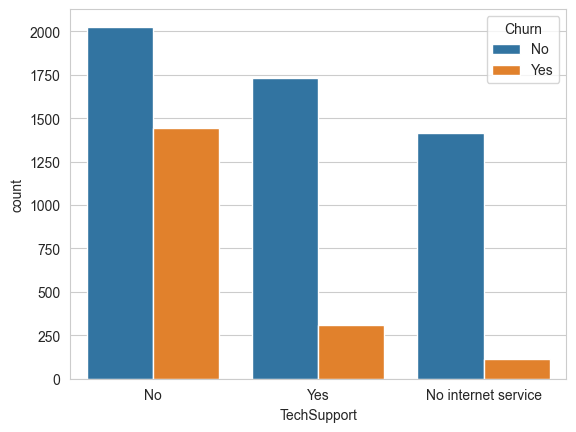

In [26]:
sns.countplot(x='TechSupport', hue='Churn', data=df)

plt.show()

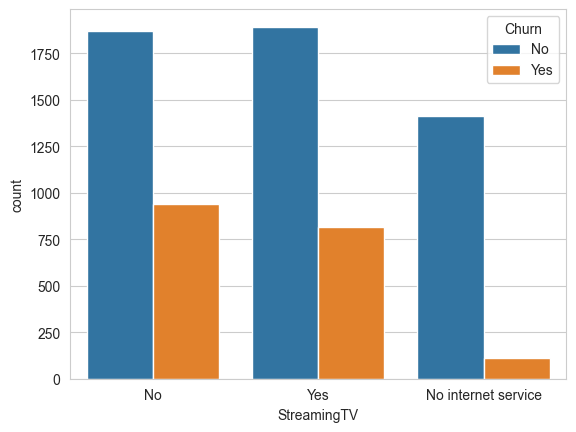

In [27]:
sns.countplot(x='StreamingTV', hue='Churn', data=df)

plt.show()

### Customer Lifetime Analysis

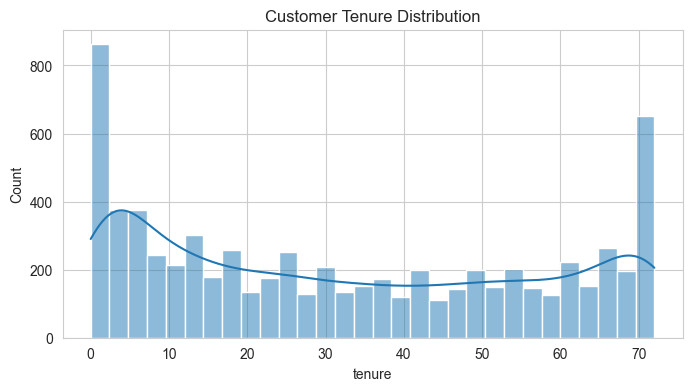

In [28]:
plt.figure(figsize=(8,4))

sns.histplot(df['tenure'], bins=30, kde=True)

plt.title("Customer Tenure Distribution")

plt.show()

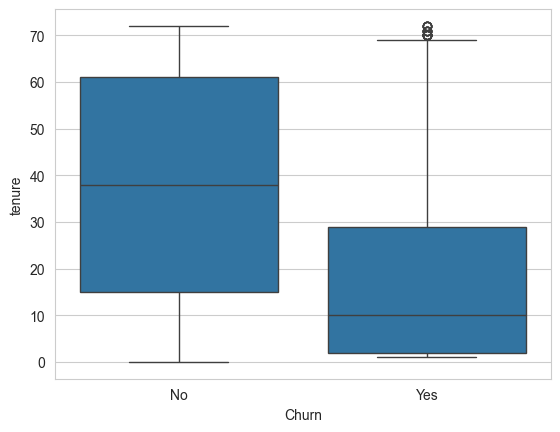

In [29]:
sns.boxplot(x='Churn', y='tenure', data=df)

plt.show()

In [30]:
df['TenureGroup'] = pd.cut(df['tenure'],bins=[0,12,24,48,72],labels=[
        '0-1 Year',
        '1-2 Years',
        '2-4 Years',
        '4-6 Years'
    ]
)

In [31]:
pd.crosstab(df['TenureGroup'], df['Churn'])

Churn,No,Yes
TenureGroup,,
0-1 Year,1138,1037
1-2 Years,730,294
2-4 Years,1269,325
4-6 Years,2026,213


### Revenue Analysis

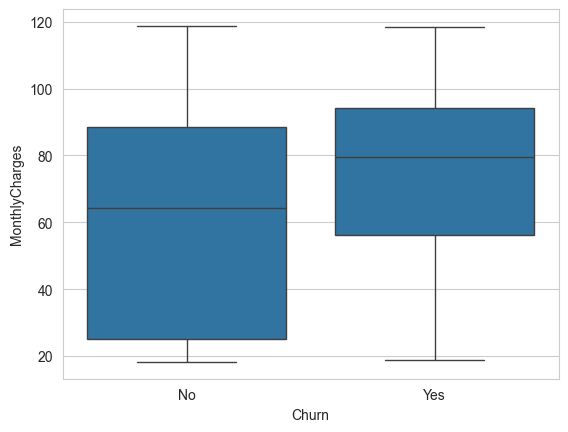

In [32]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

plt.show()

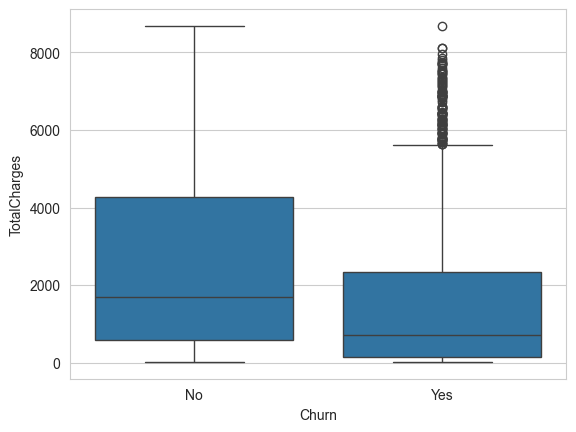

In [33]:
sns.boxplot(x='Churn', y='TotalCharges', data=df)

plt.show()

In [34]:
df.groupby('Churn')[['MonthlyCharges', 'TotalCharges']].mean()

,MonthlyCharges,TotalCharges
Churn,,
No,61.265124,2555.344141
Yes,74.441332,1531.796094


### Correlation Analysis

In [35]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

if 'customerID' in df_encoded.columns:
    df_encoded.drop('customerID', axis=1, inplace=True)

if 'TenureGroup' in df_encoded.columns:
    df_encoded.drop('TenureGroup', axis=1, inplace=True)

df_encoded['TotalCharges'] = df_encoded['TotalCharges'].fillna(
    df_encoded['TotalCharges'].median()
)

for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object' or 'str' in str(df_encoded[col].dtype):
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

print(df_encoded.info())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int64  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   int64  
 7   InternetService   7043 non-null   int64  
 8   OnlineSecurity    7043 non-null   int64  
 9   OnlineBackup      7043 non-null   int64  
 10  DeviceProtection  7043 non-null   int64  
 11  TechSupport       7043 non-null   int64  
 12  StreamingTV       7043 non-null   int64  
 13  StreamingMovies   7043 non-null   int64  
 14  Contract          7043 non-null   int64  
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   int64  
 17  Monthl

In [36]:
df_encoded.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


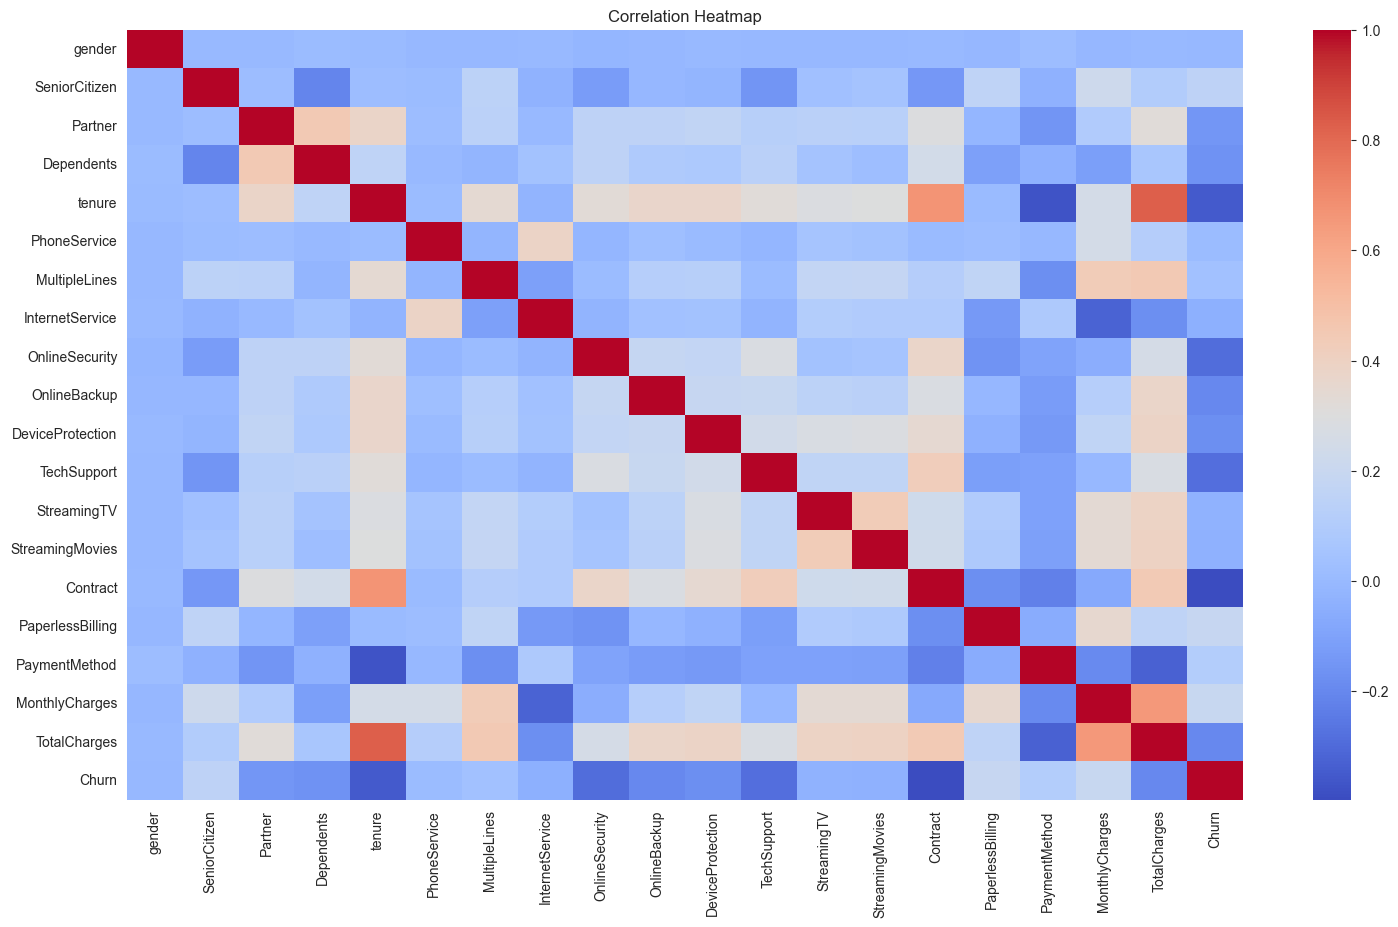

In [37]:
plt.figure(figsize=(18,10))

sns.heatmap(df_encoded.corr(numeric_only=True),cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

### Churn Prediction Model

In [38]:
X = df_encoded.drop('Churn', axis=1)

y = df_encoded['Churn']

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [40]:
rf = RandomForestClassifier( random_state=42)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [41]:
y_pred = rf.predict(X_test)

In [42]:
print("Accuracy:", accuracy_score(y_test, y_pred)) 

Accuracy: 0.7955997161107168


In [43]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.47      0.55       373

    accuracy                           0.80      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.80      0.78      1409



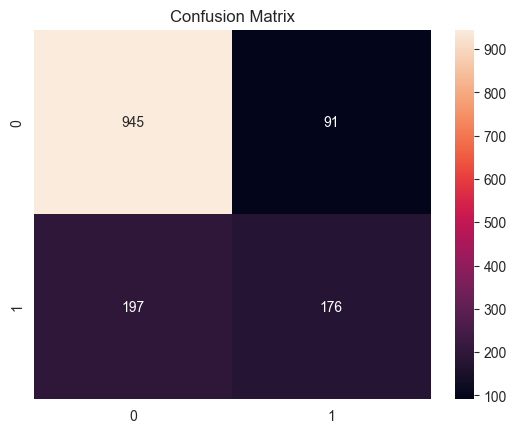

In [44]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")
plt.show()

In [45]:
importance = pd.DataFrame({

    'Feature':X.columns,
    'Importance':rf.feature_importances_
})

In [46]:
importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
18,TotalCharges,0.189992
17,MonthlyCharges,0.177867
4,tenure,0.157428
14,Contract,0.077357
16,PaymentMethod,0.050379
8,OnlineSecurity,0.047432
11,TechSupport,0.044190
0,gender,0.028117
9,OnlineBackup,0.027067
7,InternetService,0.026444


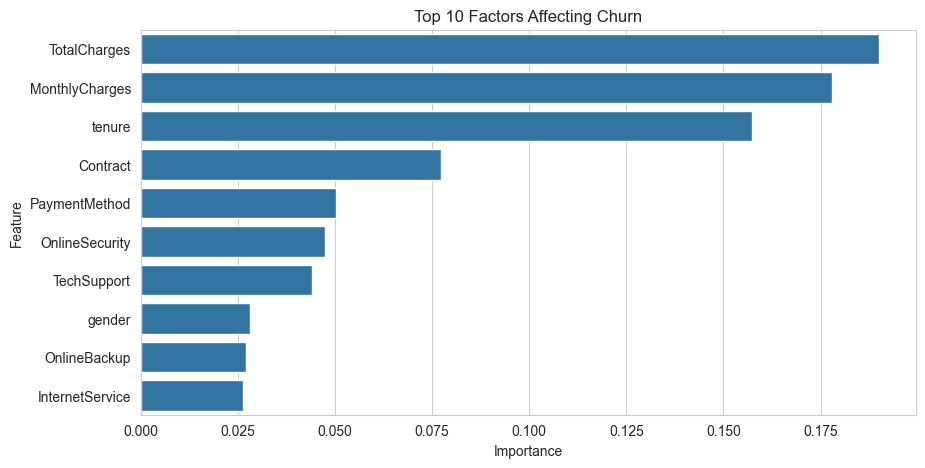

In [47]:
plt.figure(figsize=(10,5))

sns.barplot(data=importance.head(10),x='Importance',y='Feature')

plt.title("Top 10 Factors Affecting Churn")

plt.show()

In [48]:
from sklearn.metrics import roc_curve, roc_auc_score

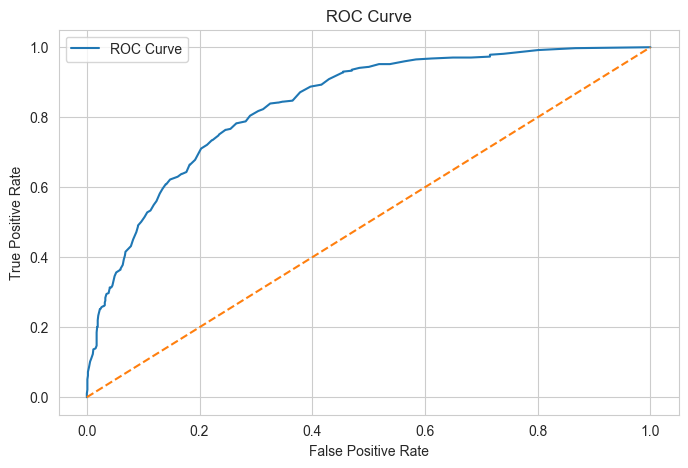

In [49]:
y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test,y_prob)

plt.figure(figsize=(8,5))

plt.plot(fpr,tpr,label='ROC Curve')

plt.plot([0,1],[0,1],linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [50]:
auc_score = roc_auc_score(y_test,y_prob)

print("AUC Score:",round(auc_score,3))

AUC Score: 0.837


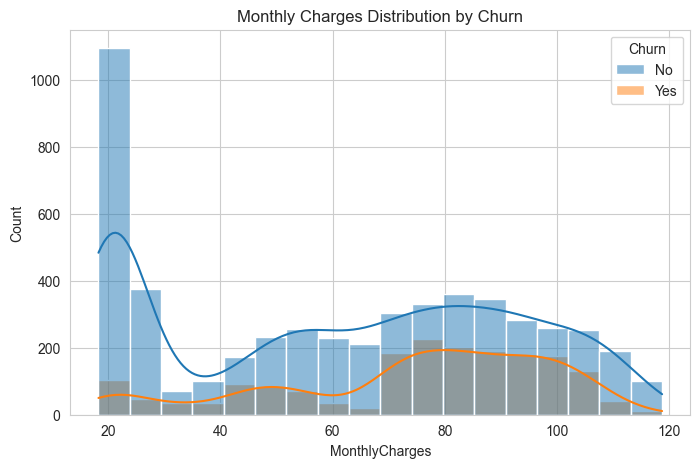

In [51]:
plt.figure(figsize=(8,5))

sns.histplot( data=df, x='MonthlyCharges', hue='Churn',kde=True)

plt.title("Monthly Charges Distribution by Churn")

plt.show()

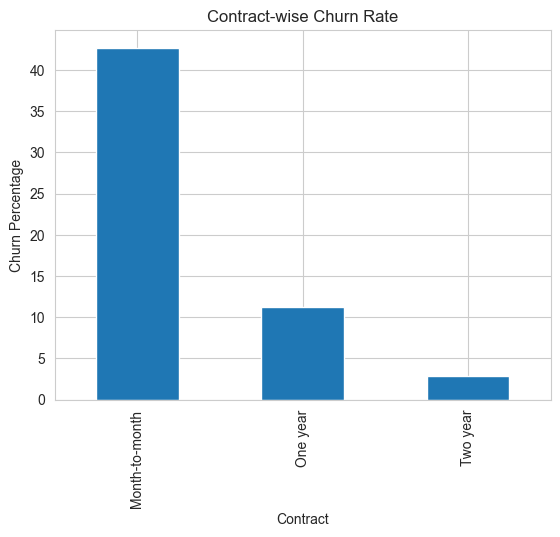

In [52]:
contract_churn = pd.crosstab(df['Contract'],df['Churn'],normalize='index')*100

contract_churn['Yes'].plot(kind='bar')

plt.ylabel("Churn Percentage")

plt.title("Contract-wise Churn Rate")

plt.show()

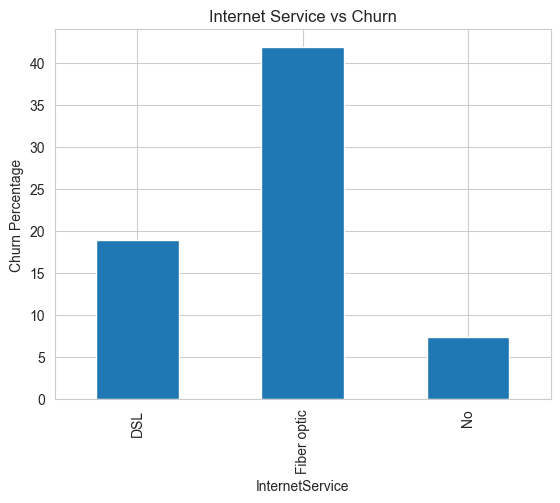

In [53]:
internet_churn = pd.crosstab(df['InternetService'],df['Churn'],normalize='index')*100

internet_churn['Yes'].plot(kind='bar')

plt.ylabel("Churn Percentage")

plt.title("Internet Service vs Churn")

plt.show()

In [54]:
importance.head(15)

,Feature,Importance
18,TotalCharges,0.189992
17,MonthlyCharges,0.177867
4,tenure,0.157428
14,Contract,0.077357
16,PaymentMethod,0.050379
8,OnlineSecurity,0.047432
11,TechSupport,0.044190
0,gender,0.028117
9,OnlineBackup,0.027067
7,InternetService,0.026444


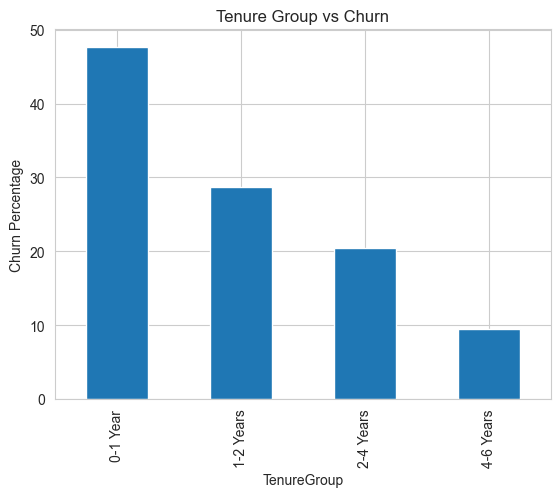

In [55]:
tenure_churn = pd.crosstab(df['TenureGroup'],df['Churn'],normalize='index')*100

tenure_churn['Yes'].plot(kind='bar')

plt.ylabel("Churn Percentage")

plt.title("Tenure Group vs Churn")

plt.show()

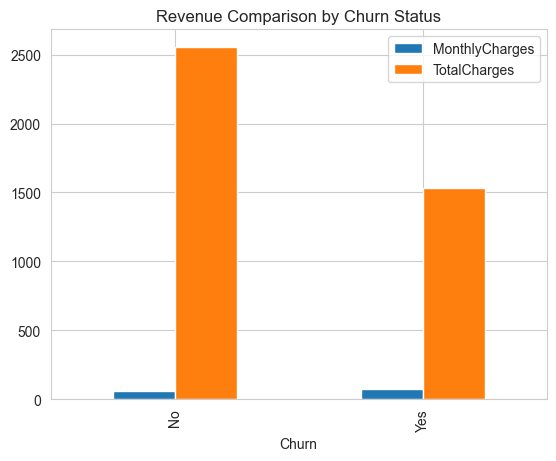

In [56]:
df.groupby('Churn')[['MonthlyCharges','TotalCharges']].mean().plot(kind='bar')

plt.title("Revenue Comparison by Churn Status")

plt.show()

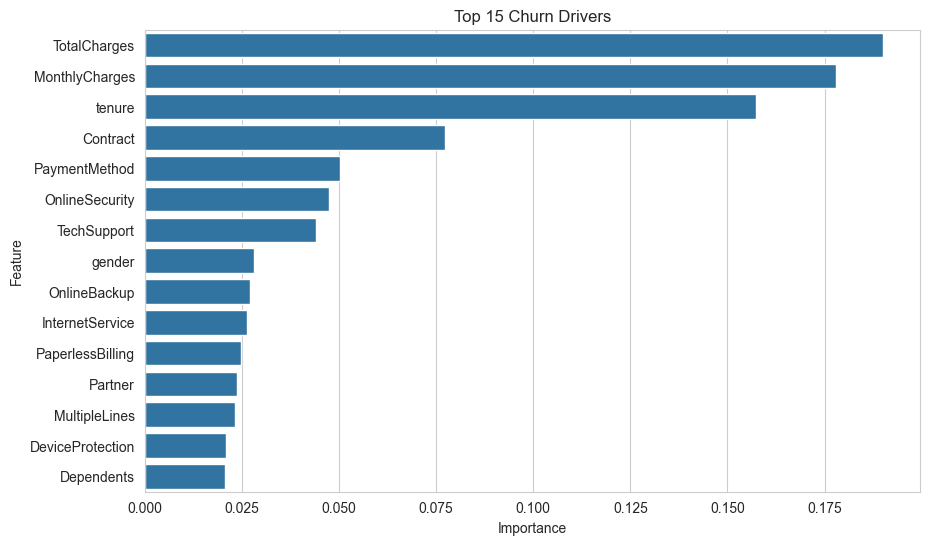

In [57]:
top15 = importance.head(15)

plt.figure(figsize=(10,6))

sns.barplot(data=top15,x='Importance',y='Feature')

plt.title("Top 15 Churn Drivers")

plt.show()

In [58]:
summary = pd.DataFrame({

    'Metric':[
        'Total Customers',
        'Churn Rate (%)',
        'Model Accuracy',
        'AUC Score'
    ],

    'Value':[len(df),round(churn_rate['Yes'],2),

        round(accuracy_score(y_test,y_pred),3),

        round(auc_score,3)
    ]})

summary

,Metric,Value
0,Total Customers,7043.000
1,Churn Rate (%),26.540
2,Model Accuracy,0.796
3,AUC Score,0.837


## Key Business Insights

1. Month-to-month contracts have the highest churn rate.
2. Customers with shorter tenure are more likely to leave.
3. Senior citizens show higher churn behavior.
4. Electronic check users churn more frequently.
5. Customers without online security are more likely to churn.
6. Customers without tech support have higher churn rates.
7. Higher monthly charges contribute to churn.
8. Long-term contracts improve retention significantly.
9. New customers represent the highest-risk segment.
10. Customer tenure is one of the strongest churn indicators.

### Recommendations

1. Promote yearly contracts with discounts.
2. Improve onboarding for new customers.
3. Offer retention campaigns for high-risk users.
4. Encourage use of online security services.
5. Improve technical support experience.
6. Reward loyal customers.
7. Monitor customers with high monthly charges.
8. Create targeted retention offers.
9. Build a churn monitoring dashboard.
10. Implement proactive customer engagement strategies.

### Conclusion

This project analyzed customer churn behavior using the Telco Customer Churn dataset.

The analysis revealed that tenure, contract type, monthly charges, payment method, and support services significantly influence customer retention.

By encouraging long-term contracts, improving onboarding, and proactively supporting high-risk customers, businesses can reduce churn and improve customer lifetime value.